<a id='section-2'></a>

# Feature Engineering & Segment-Level Churn Analysis

In this section, we derive temporal, pricing, and consumption-based features to better understand customer behavior and identify churn patterns across key customer segments.

The notebook includes:

- Temporal customer features (tenure, contract expiry, modification recency)
- Average and changing price metrics
- Customer segmentation by tenure, products, gas subscriptions, and sales channels
- Profiling churned vs retained customers

In [19]:

# Load datasets and parse date columns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

date_cols = ['date_activ', 'date_end', 'date_modif_prod', 'date_renewal']

client = pd.read_csv("D:\Data Analysis\customer_churn_analysis\client_data.csv", parse_dates=date_cols)

price = pd.read_csv("D:\Data Analysis\customer_churn_analysis\price_data.csv", parse_dates=['price_date'])

REF_DATE = pd.Timestamp('2016-01-01')         # end-of-observation reference

print(f"Reference date: {REF_DATE.date()}")


Reference date: 2016-01-01


### Customer Temporal Features

We create several customer-level features that capture contract duration, expiry timing, product modification recency, and consumption trends.

In [3]:

# Customer temporal features

client['tenure_years'] = ((REF_DATE - client['date_activ']).dt.days / 365)

client['months_to_end'] = ((client['date_end'] - REF_DATE).dt.days / 30)

client['months_since_mod'] = ((REF_DATE - client['date_modif_prod']).dt.days / 30)

# Consumption trend
client['cons_trend'] = (client['cons_last_month'] * 12 - client['cons_12m'])

print("New client features created:")
print(" • tenure_years")
print(" • months_to_end")
print(" • months_since_mod")
print(" • cons_trend")


New client features created:
 • tenure_years
 • months_to_end
 • months_since_mod
 • cons_trend


### Pricing Features

Price data is aggregated to the customer level by calculating:

- Average prices across all available months
- Absolute price changes between the first and last observations
- Percentage change in off-peak variable pricing

In [4]:

# Average price features per customer

price_mean = (price.groupby('id')[['price_off_peak_var', 'price_peak_var', 'price_mid_peak_var', 'price_off_peak_fix', 'price_peak_fix']].mean().reset_index())

price_mean.columns = ['id', 'mean_opv', 'mean_pkv', 'mean_mpv', 'mean_opf', 'mean_pkf']


In [5]:

# Price change features: Jan → Dec 2015

price_sorted = price.sort_values(['id', 'price_date'])

p_first = (price_sorted.groupby('id').first().reset_index())

p_last = (price_sorted.groupby('id').last().reset_index())

price_delta = pd.DataFrame({'id': p_first['id'], 
                            'delta_off_peak_var': p_last['price_off_peak_var'].values - p_first['price_off_peak_var'].values,
                            'delta_off_peak_fix': p_last['price_off_peak_fix'].values - p_first['price_off_peak_fix'].values,
                            'delta_peak_var': p_last['price_peak_var'].values - p_first['price_peak_var'].values})

price_delta['pct_chg_off_peak'] = np.where(p_first['price_off_peak_var'].values != 0,
                                           price_delta['delta_off_peak_var'] / p_first['price_off_peak_var'].values, 0)

print("Price features created successfully.")


Price features created successfully.


### Create Analytical Dataset

Merge customer and pricing features into a single modeling dataset.

In [6]:

# Merge all engineered features

df = (client.merge(price_mean, on='id', how='left').merge(price_delta, on='id', how='left'))

print(f"Merged dataframe shape: {df.shape}")
print(f"Overall churn rate: {df['churn'].mean()*100:.2f}%")

df.head(3)


Merged dataframe shape: (14606, 39)
Overall churn rate: 9.72%


,id,channel_sales,cons_12m,cons_gas_12m,cons_last_month,date_activ,date_end,date_modif_prod,date_renewal,forecast_cons_12m,...,cons_trend,mean_opv,mean_pkv,mean_mpv,mean_opf,mean_pkf,delta_off_peak_var,delta_off_peak_fix,delta_peak_var,pct_chg_off_peak
0,24011ae4ebbe3035111d65fa7c15bc57,foosdfpfkusacimwkcsosbicdxkicaua,0,54946,0,2013-06-15,2016-06-15,2015-11-01,2015-06-23,0.00,...,0,0.124787,0.100749,0.06653,40.942265,22.35201,0.020057,3.700961,-0.017912,0.159213
1,d29c2c54acc38ff3c0614d0a653813dd,MISSING,4660,0,0,2009-08-21,2016-08-30,2009-08-21,2015-08-31,189.95,...,-4660,0.149609,0.007124,0.00000,44.311375,0.00000,-0.003767,0.177779,0.000000,-0.024887
2,764c75f661154dac3a6c254cd082ea7d,foosdfpfkusacimwkcsosbicdxkicaua,544,0,0,2010-04-16,2016-04-16,2010-04-16,2015-04-17,47.96,...,-544,0.170512,0.088421,0.00000,44.385450,0.00000,-0.004670,0.177779,0.000528,-0.027077


In [7]:

# save merged dataset

df.to_csv("D:\Data Analysis\customer_churn_analysis\modeling_data.csv", index=False)


---
## Segment-Level Churn Analysis

We examine churn rates across several customer segments:

- Tenure groups
- Gas add-on subscription
- Number of active products
- Sales channel

In [8]:

# Churn by tenure bucket

df['tenure_bucket'] = pd.cut(df['tenure_years'], bins=[0, 1, 3, 5, 10, 100], labels=['<1 yr', '1–3 yr', '3–5 yr', '5–10 yr', '10+ yr'])

tenure_churn = (df.groupby('tenure_bucket', observed=False)['churn'].agg(churn_rate='mean', customer_count='count'))

tenure_churn['churn_rate'] = (tenure_churn['churn_rate'] * 100).round(2)

print("Churn Rate by Tenure Bucket")
display(tenure_churn)


Churn Rate by Tenure Bucket


,churn_rate,customer_count
tenure_bucket,,
<1 yr,NaN,0
1–3 yr,15.27,1225
3–5 yr,11.27,6458
5–10 yr,7.29,6556
10+ yr,7.08,367


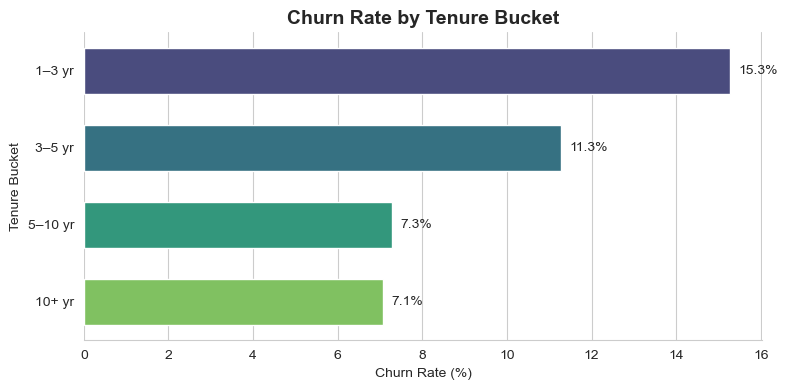

In [110]:

# Reset index for plotting
df = tenure_churn.reset_index()
# Remove bucket with no customers / NaN churn rate
plot_df = df[df['customer_count'] > 0].copy()

plot_df['tenure_bucket'] = plot_df['tenure_bucket'].astype(str)

sns.set_style("whitegrid")

plt.figure(figsize=(8, 4))

ax = sns.barplot(data=plot_df, x="churn_rate", y="tenure_bucket", palette = "viridis", width=0.6)

# Add labels
for i, v in enumerate(plot_df["churn_rate"]):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center")

plt.title("Churn Rate by Tenure Bucket", fontsize=14, weight="bold")
plt.xlabel("Churn Rate (%)")
plt.ylabel("Tenure Bucket")

sns.despine(left=True)
plt.tight_layout()
plt.show()


In [9]:

# Churn by gas subscription

gas_churn = (df.groupby('has_gas')['churn'].agg(churn_rate='mean', customer_count='count'))

gas_churn['churn_rate'] = (gas_churn['churn_rate'] * 100).round(2)

display(gas_churn)

diff = (gas_churn.loc['f', 'churn_rate'] - gas_churn.loc['t', 'churn_rate'])

print(f"Gas customers churn " f"{diff:.1f} percentage points less.")


,churn_rate,customer_count
has_gas,,
f,10.05,11955
t,8.19,2651


Gas customers churn 1.9 percentage points less.


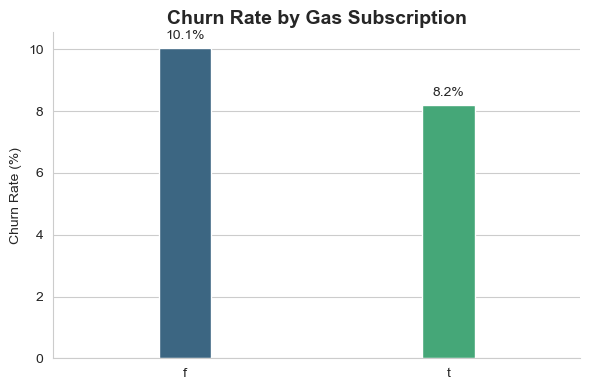

In [111]:

plot_df = gas_churn.reset_index()

sns.set_style("whitegrid")

plt.figure(figsize=(6, 4))

ax = sns.barplot(data=plot_df,x="has_gas", y="churn_rate", palette= "viridis", width=0.2) 
                 
# Add labels
for i, v in enumerate(plot_df["churn_rate"]):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")

plt.title("Churn Rate by Gas Subscription", fontsize=14, weight="bold")
plt.xlabel("")
plt.ylabel("Churn Rate (%)")

sns.despine()
plt.tight_layout()
plt.show()


In [10]:

# Churn by number of active products

prod_churn = (df.groupby('nb_prod_act')['churn'].agg(churn_rate='mean', customer_count='count'))

prod_churn['churn_rate'] = (prod_churn['churn_rate'] * 100).round(2)

display(prod_churn)


,churn_rate,customer_count
nb_prod_act,,
1,9.98,11431
2,8.51,2445
3,9.94,523
4,10.00,150
5,9.68,31
6,0.00,8
8,0.00,4
9,0.00,11
10,0.00,2


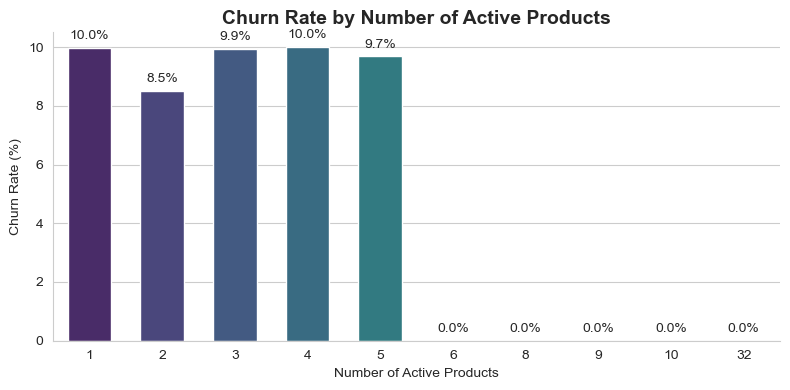

In [121]:

plot_df = prod_churn.reset_index()

sns.set_style("whitegrid")

plt.figure(figsize=(8, 4))

ax = sns.barplot(data=plot_df, x="nb_prod_act", y="churn_rate", palette="viridis", width=0.6)

# Add labels
for i, v in enumerate(plot_df["churn_rate"]):
    ax.text(i, v + 0.3, f"{v:.1f}%", ha="center")

plt.title("Churn Rate by Number of Active Products", fontsize=14, weight="bold")

plt.xlabel("Number of Active Products")
plt.ylabel("Churn Rate (%)")

sns.despine()
plt.tight_layout()
plt.show()


In [11]:

# Churn by sales channel

channel_churn = (df.groupby('channel_sales')['churn'].agg(churn_rate='mean', customer_count='count'))

channel_churn['churn_rate'] = (channel_churn['churn_rate'] * 100).round(2)

channel_churn = channel_churn.sort_values('churn_rate', ascending=False)

display(channel_churn)


,churn_rate,customer_count
channel_sales,,
foosdfpfkusacimwkcsosbicdxkicaua,12.14,6754
usilxuppasemubllopkaafesmlibmsdf,10.04,1375
ewpakwlliwisiwduibdlfmalxowmwpci,8.40,893
MISSING,7.60,3725
lmkebamcaaclubfxadlmueccxoimlema,5.59,1843
epumfxlbckeskwekxbiuasklxalciiuu,0.00,3
fixdbufsefwooaasfcxdxadsiekoceaa,0.00,2
sddiedcslfslkckwlfkdpoeeailfpeds,0.00,11


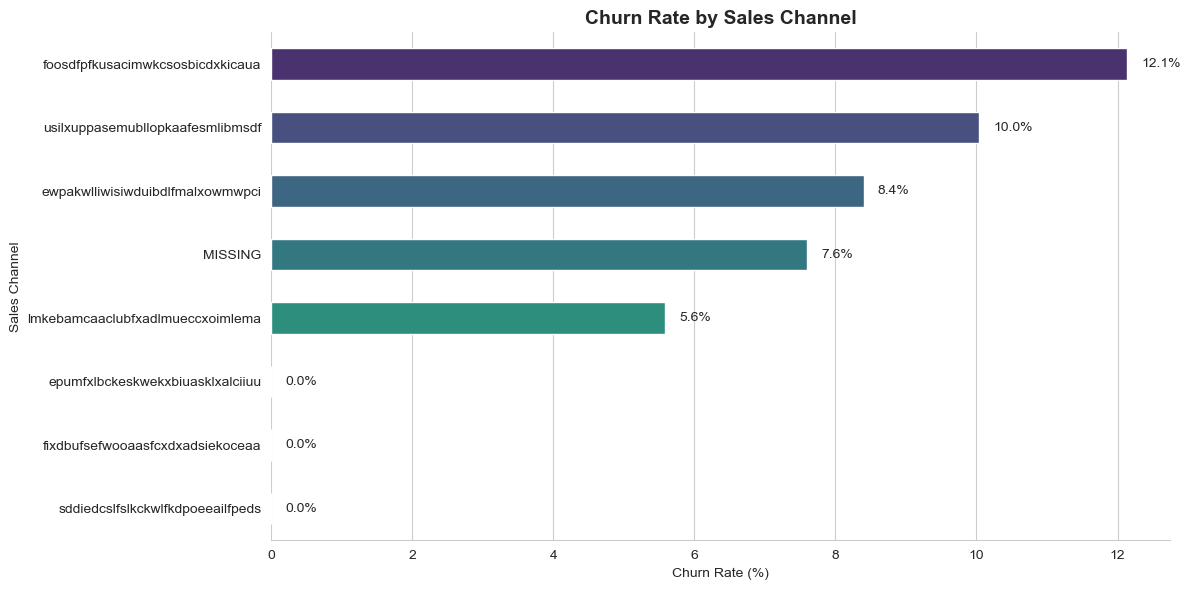

In [132]:

plot_df = channel_churn.reset_index()

sns.set_style("whitegrid")

plt.figure(figsize=(12, 6))

ax = sns.barplot(data=plot_df, x="churn_rate", y="channel_sales", palette="viridis", width=0.5)

# Add labels
for i, v in enumerate(plot_df["churn_rate"]):
    ax.text(v + 0.2, i, f"{v:.1f}%", va="center")

plt.title("Churn Rate by Sales Channel", fontsize=14, weight="bold")

plt.xlabel("Churn Rate (%)")
plt.ylabel("Sales Channel")

sns.despine(left=True)
plt.tight_layout()
plt.show()


---
## Churned vs Retained Customer Profile

Finally, compare the average characteristics of churned and retained customers to identify meaningful behavioral and financial differences.

In [12]:

# Customer Profile Comparison
# Churned vs retained customer profile

profile_cols = ['cons_12m', 'cons_gas_12m', 'net_margin', 'tenure_years', 'nb_prod_act', 'pow_max', 'mean_opv', 'mean_pkv', 'delta_off_peak_var']

profile = (df.groupby('churn')[profile_cols].mean().T.rename(
    columns={
        0: 'Retained',
        1: 'Churned'
    })
)

profile['pct_diff'] = ((profile['Churned'] - profile['Retained']) / profile['Retained'] * 100).round(1)

display(profile.round(4))


churn,Retained,Churned,pct_diff
cons_12m,167867.2666,78862.4785,-53.0
cons_gas_12m,30121.4973,9235.4116,-69.3
net_margin,185.0574,228.3619,23.4
tenure_years,4.9675,4.5597,-8.2
nb_prod_act,1.2958,1.2600,-2.8
pow_max,18.0003,19.3878,7.7
mean_opv,0.1424,0.1419,-0.3
mean_pkv,0.0516,0.0566,9.7
delta_off_peak_var,-0.0046,-0.0046,0.9
